
=== [i = 0] flat_dir = ./0/lambda_triplet20, V = -0.010000, μ_fixed = +8.652472e-04 ===


/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:825: UserWarning: Setting `gtol` below the machine epsilon (2.22e-16) effectively disables the corresponding termination condition.
  ftol, xtol, gtol = check_tolerance(ftol, xtol, gtol, method)


[fixed μ=+8.652472e-04] success=True resnorm=1.282e-18 msg=`xtol` termination condition is satisfied.
Δ0=+1.754298e-03+8.968825e-10j, Δ1=+1.754298e-03+8.968825e-10j
Δ0=+1.754298e-03+8.968825e-10j, Δ1=+1.754298e-03+8.968825e-10j, μ=+8.652472e-04
check: Δ0−V*acc0=-1.084e-18-2.375e-19j, Δ1−V*acc1=-2.168e-19+6.042e-19j, resnorm=1.28e-18

=== [i = 1] flat_dir = ./1/lambda_triplet20, V = -0.010000, μ_fixed = +8.652472e-04 ===
[fixed μ=+8.652472e-04] success=True resnorm=5.350e-19 msg=`xtol` termination condition is satisfied.
Δ0=+2.853164e-03+1.851043e-09j, Δ1=+2.853164e-03+1.851043e-09j
Δ0=+2.853164e-03+1.851043e-09j, Δ1=+2.853164e-03+1.851043e-09j, μ=+8.652472e-04
check: Δ0−V*acc0=+4.337e-19+2.460e-19j, Δ1−V*acc1=+0.000e+00+1.940e-19j, resnorm=5.35e-19

=== [i = 2] flat_dir = ./2/lambda_triplet20, V = -0.010000, μ_fixed = +8.652472e-04 ===
[fixed μ=+8.652472e-04] success=True resnorm=2.634e-18 msg=`xtol` termination condition is satisfied.
Δ0=+3.943579e-03+1.456919e-08j, Δ1=+3.943579e-03+1

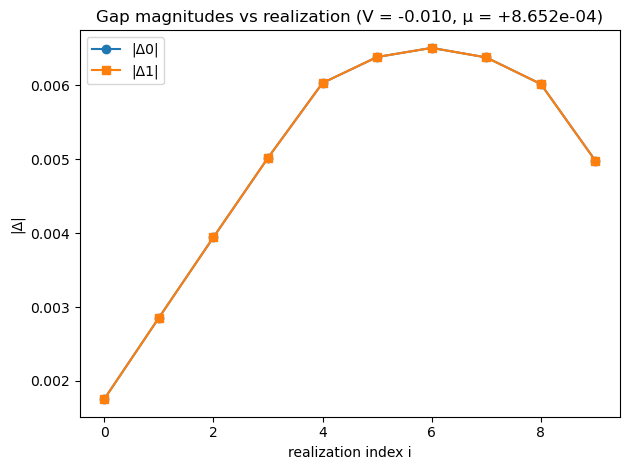

In [1]:
import os
import re
import glob
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global cache: avoid re-loading .npz on every residual call
# ------------------------------------------------------------
_flat_cache = {}

def load_flatpack(k_index, flat_dir="lambda_singlet"):
    """
    Load and cache flat-band data for a given k_index.
    Expects files named flat_kXXXXX.npz inside flat_dir.
    """
    k_index = int(k_index)
    key = (flat_dir, k_index)
    if key in _flat_cache:
        return _flat_cache[key]

    path = os.path.join(flat_dir, f"flat_k{k_index:05d}.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    z = np.load(path, allow_pickle=True)
    pack = {
        "L0flat":     z["L0flat"],          # shape: (3, N, N)
        "L1flat":     z["L1flat"],          # shape: (3, N, N)
        "Eplus_flat":  z["Eplus_flat"],     # shape: (N,)
        "Eminus_flat": z["Eminus_flat"],    # shape: (N,)
        "k":          z["k"],
        "k_index":    int(z["k_index"]),
    }
    _flat_cache[key] = pack
    return pack

# ------------------------------------------------------------
# Helper: centered subspace indices
# ------------------------------------------------------------
def _center_indices(N, subspace_dim):
    """
    Return indices for a centered subspace of size subspace_dim inside 0..N-1.
    """
    if subspace_dim > N:
        raise ValueError(f"subspace_dim={subspace_dim} > full dim N={N}")
    start = (N - subspace_dim) // 2
    end   = start + subspace_dim
    return np.arange(start, end, dtype=int)

# ------------------------------------------------------------
# Flat-band BdG Hamiltonian (restricted subspace)
# ------------------------------------------------------------
def flat_BdG(pack, *, DeltaLayer0, DeltaLayer1, mu,
             subspace_dim=10):
    """
    Build flat-band BdG Hamiltonian in a centered subspace of size subspace_dim.
    Δ0, Δ1 are length-3 complex arrays (one component per Kekulé irrep).
    """
    Δ0 = np.asarray(DeltaLayer0, complex).ravel()
    Δ1 = np.asarray(DeltaLayer1, complex).ravel()
    if Δ0.size != 3 or Δ1.size != 3:
        raise ValueError("DeltaLayer0/1 must each have length 3.")

    Eplus  = np.asarray(pack["Eplus_flat"],  float)
    Eminus = np.asarray(pack["Eminus_flat"], float)
    L0flat = np.asarray(pack["L0flat"])   # (3, N, N)
    L1flat = np.asarray(pack["L1flat"])   # (3, N, N)

    N = Eplus.shape[0]
    idx = _center_indices(N, subspace_dim)

    # restrict to subspace
    Eplus_sub  = Eplus[idx]
    Eminus_sub = Eminus[idx]
    L0_sub = L0flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)
    L1_sub = L1flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)

    Fp = np.diag(Eplus_sub)
    Fm = -np.diag(Eminus_sub)

    # pairing: here only sym = 0 component used; Lflat is mathematical Λ
    Gap_flat = Δ0[0] * np.conj(L0_sub[0]) + Δ1[0] * np.conj(L1_sub[0])

    I = np.eye(Fp.shape[0], dtype=complex)
    HLL = np.block([
        [Fp - mu * I,          -Gap_flat        ],
        [-Gap_flat.conj().T,    Fm + mu * I     ]
    ]).astype(complex)

    return HLL, Gap_flat,Eminus_sub

# ------------------------------------------------------------
# Lambda in flat subspace
# ------------------------------------------------------------
def Lambda_Flat(pack_flat, *, layer=0, sym=0, subspace_dim=10):
    """
    Return Λ (conjugated) in the same centered subspace as flat_BdG.
    Mathematical Λ = Lflat[sym]. Here we return conj(Λ) so that
    np.vdot(Lambda, F) = tr(Λ^T F).
    """
    Lflat_all = np.asarray(pack_flat["L0flat" if layer == 0 else "L1flat"])
    Lfull_math = Lflat_all[sym]              # Λ_math, shape (N, N)
    Lambda_full = np.conj(Lfull_math)        # Λ_code = conj(Λ_math)

    N = Lambda_full.shape[0]
    idx = _center_indices(N, subspace_dim)
    Lambda = Lambda_full[idx][:, idx]        # (subspace_dim, subspace_dim)
    return Lambda

# ------------------------------------------------------------
# Anomalous correlator F
# ------------------------------------------------------------
def Anomalous(pack, *, DeltaLayer0, DeltaLayer1, mu, T=1e-3,
              subspace_dim=10):
    """
    Compute anomalous correlator F = G_{12} in the truncated subspace.
    Uses Matsubara-like tanh kernel: t = -1/2 tanh(βE/2).
    """
    HLL, _,_ = flat_BdG(pack, DeltaLayer0=DeltaLayer0,
                      DeltaLayer1=DeltaLayer1,
                      mu=mu, subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)

    beta = 1.0 / float(T)
    x = 0.5 * beta * np.asarray(E)
    t = -0.5 * np.tanh(x)
    G = (U * t) @ U.conj().T
    n = HLL.shape[0] // 2
    F = -G[:n, n:]   # particle-hole block
    return F, (E, U)

# ------------------------------------------------------------
# Brillouin-zone integration: gap contractions only (no density)
# ------------------------------------------------------------
def IntegrateBZ_acc(*, DeltaLayer0, DeltaLayer1,
                    sym=0, T=1e-3,
                    mu_fixed=1e-3,
                    flat_dir="lambda_singlet",
                    average=True,
                    subspace_dim=10):
    """
    Loop over all k-points in flat_dir and accumulate:
        acc0 = <Λ0, F>
        acc1 = <Λ1, F>
    Everything is done in one BZ sweep using the same (E, U).
    Particle number density is NOT computed here.
    """
    files = sorted(
        fn for fn in os.listdir(flat_dir)
        if re.match(r"flat_k\d{5}\.npz$", fn)
    )
    if not files:
        raise FileNotFoundError(f"No flat_kXXXXX.npz files found in {flat_dir}")

    acc0 = 0j
    acc1 = 0j
    Nk = 0

    for fn in files:
        k_index = int(fn[6:11])
        pack = load_flatpack(k_index, flat_dir=flat_dir)

        # anomalous block + spectrum
        F, _ = Anomalous(
            pack,
            DeltaLayer0=DeltaLayer0,
            DeltaLayer1=DeltaLayer1,
            mu=mu_fixed, T=T,
            subspace_dim=subspace_dim
        )

        # gap contractions: Gamma = conj(Λ_math)
        Gamma0 = Lambda_Flat(pack, layer=0, sym=sym, subspace_dim=subspace_dim)
        Gamma1 = Lambda_Flat(pack, layer=1, sym=sym, subspace_dim=subspace_dim)
        # np.vdot(Gamma, F) = sum conj(Gamma)*F = sum Λ_math * F = tr(Λ_math^T F)
        acc0 += np.vdot(Gamma0, F)
        acc1 += np.vdot(Gamma1, F)

        Nk += 1

    if average and Nk:
        acc0 /= Nk
        acc1 /= Nk

    return acc0, acc1

# ------------------------------------------------------------
# Solve gap equations at fixed μ
# ------------------------------------------------------------
def solve_gap_fixed_mu(*, sym=0, V=-1.0, T=1e-3,
                       mu_fixed=1e-3,
                       flat_dir="lambda_singlet",
                       x0=(5e-2, 0.0, -5e-2, 0.0),  # (ReΔ0, ImΔ0, ReΔ1, ImΔ1)
                       max_nfev=2000, verbose=True,
                       subspace_dim=10):
    """
    Solve for (Δ0, Δ1) at fixed chemical potential μ = mu_fixed such that:
      Δ0 = V * acc0,  Δ1 = V * acc1.

    This version:
      - Uses gtol=0.0 to avoid premature 'gradient' termination.
      - Leaves ftol, xtol controlling actual convergence in residual / step.
    """
    x0 = np.asarray([x0[0], x0[1], x0[2], x0[3]], float)

    def residuals(x):
        d0 = complex(x[0], x[1])
        d1 = complex(x[2], x[3])

        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        acc0, acc1 = IntegrateBZ_acc(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            sym=sym,
            T=T,
            mu_fixed=mu_fixed,
            flat_dir=flat_dir,
            average=True,
            subspace_dim=subspace_dim
        )

        # gap equations (complex -> 4 real equations)
        r0 = d0 - V * acc0
        r1 = d1 - V * acc1

        return np.array([r0.real, r0.imag, r1.real, r1.imag], float)

    ls = least_squares(
        residuals, x0, method="trf",
        ftol=1e-10, xtol=1e-10, gtol=0.0,   # <-- gtol disabled
        max_nfev=max_nfev
    )

    d0 = complex(ls.x[0], ls.x[1])
    d1 = complex(ls.x[2], ls.x[3])
    resnorm = float(np.linalg.norm(ls.fun))

    if verbose:
        print(f"[fixed μ={mu_fixed:+.6e}] success={ls.success} "
              f"resnorm={resnorm:.3e} msg={ls.message}")
        print(f"Δ0={d0:+.6e}, Δ1={d1:+.6e}")

    info = {
        "success": bool(ls.success),
        "resnorm": resnorm,
        "message": ls.message,
    }
    # Return μ as mu_fixed just for bookkeeping
    return (d0, d1, mu_fixed), info


# ------------------------------------------------------------
# Sweep over i/lambda_singlet with fixed V and fixed μ (with retries)
# ------------------------------------------------------------
def sweep_realizations(*, sym=0, T=1e-3,
                       V=-0.03,
                       mu_fixed=1e-3,
                       i_min=0, i_max=10,
                       base_dir=".",
                       x0=(5e-2, 0.0, -5e-2, 0.0),
                       max_nfev=2000,
                       verbose=True,
                       subspace_dim=10,
                       res_tol=1e-6):
    """
    Sweep realizations i = i_min..i_max.

    - Uses previous solution as seed IF it was good (resnorm < res_tol).
    - If a solve yields resnorm > res_tol, it retries with:
        (1) the original user-provided seed x0, and if still bad,
        (2) a very small-gap initial guess (almost normal state).
    """
    rows = []

    # base seeds
    global_seed = np.array(x0, float)  # original seed you pass in
    seed_x = global_seed.copy()        # rolling seed

    for i in range(i_min, i_max + 1):
        # ---- clear cache so we don't accumulate all realizations in RAM ----
        global _flat_cache
        _flat_cache.clear()

        flat_dir = os.path.join(base_dir, str(i), "lambda_triplet20")

        if verbose:
            print(f"\n=== [i = {i}] flat_dir = {flat_dir}, V = {V:+.6f}, "
                  f"μ_fixed = {mu_fixed:+.6e} ===")

        # 1st attempt: use rolling seed
        (d0, d1, mu), info = solve_gap_fixed_mu(
            sym=sym,
            V=V,
            T=T,
            mu_fixed=mu_fixed,
            flat_dir=flat_dir,
            x0=seed_x,
            max_nfev=max_nfev,
            verbose=verbose,
            subspace_dim=subspace_dim
        )

        # If residual is too large, try more conservative seeds
        if info["resnorm"] > res_tol:
            if verbose:
                print(f"  resnorm={info['resnorm']:.3e} > {res_tol:.1e}, "
                      f"retrying with global seed {global_seed}...")
            (d0, d1, mu), info = solve_gap_fixed_mu(
                sym=sym,
                V=V,
                T=T,
                mu_fixed=mu_fixed,
                flat_dir=flat_dir,
                x0=global_seed,
                max_nfev=max_nfev,
                verbose=verbose,
                subspace_dim=subspace_dim
            )

        if info["resnorm"] > res_tol:
            if verbose:
                print(f"  resnorm still high ({info['resnorm']:.3e}), "
                      f"retrying with tiny-gap normal seed...")
            tiny_seed = (1e-4, 0.0, 1e-4, 0.0)
            (d0, d1, mu), info = solve_gap_fixed_mu(
                sym=sym,
                V=V,
                T=T,
                mu_fixed=mu_fixed,
                flat_dir=flat_dir,
                x0=tiny_seed,
                max_nfev=max_nfev,
                verbose=verbose,
                subspace_dim=subspace_dim
            )

        # Decide what to use as the next rolling seed:
        # - if good, propagate this solution;
        # - if still bad, fall back to global_seed so we don't "pollute" later i.
        if info["resnorm"] < res_tol:
            seed_x = np.array([d0.real, d0.imag, d1.real, d1.imag], float)
        else:
            if verbose:
                print(f"  WARNING: final resnorm={info['resnorm']:.3e} "
                      f"> {res_tol:.1e} for i={i}, not updating seed_x.")
            seed_x = global_seed.copy()

        # For bookkeeping and checks
        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        acc0, acc1 = IntegrateBZ_acc(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            sym=sym,
            T=T,
            mu_fixed=mu,
            flat_dir=flat_dir,
            average=True,
            subspace_dim=subspace_dim
        )

        rows.append({
            "i": i,
            "flat_dir": flat_dir,
            "V": V,
            "Δ0": d0,
            "Δ1": d1,
            "μ": mu,
            "resnorm": info["resnorm"],
            "success": info["success"],
            "Δ0_minus_Vacc0": d0 - V * acc0,
            "Δ1_minus_Vacc1": d1 - V * acc1,
        })

        if verbose:
            print(f"Δ0={d0:+.6e}, Δ1={d1:+.6e}, μ={mu:+.6e}")
            print(f"check: Δ0−V*acc0={rows[-1]['Δ0_minus_Vacc0']:+.3e}, "
                  f"Δ1−V*acc1={rows[-1]['Δ1_minus_Vacc1']:+.3e}, "
                  f"resnorm={info['resnorm']:.2e}")

    return rows


if __name__ == "__main__":
    sym = 0
    T = 1e-6
    V_fixed = -0.01       # <-- choose your fixed V here
    mu_fixed = +8.652472e-04  # <-- FIXED chemical potential
    prev = (+3e-3, +0.0,  3e-3, -0.0)   # (ReΔ0, ImΔ0, ReΔ1, ImΔ1)
    max_nfev = 800
    verbose = True
    subspace_dim = 20

    results = sweep_realizations(
        sym=sym,
        T=T,
        V=V_fixed,
        mu_fixed=mu_fixed,
        i_min=0,
        i_max=9,
        base_dir=".",  # or the base path where 0/,1/,... live
        x0=prev,
        max_nfev=max_nfev,
        verbose=verbose,
        subspace_dim=subspace_dim
    )

    idx = np.array([r["i"]  for r in results], int)
    D0  = np.array([r["Δ0"] for r in results], complex)
    D1  = np.array([r["Δ1"] for r in results], complex)
    MU  = np.array([r["μ"]  for r in results], float)
    RES = np.array([r["resnorm"] for r in results], float)

    plt.figure()
    plt.plot(idx, np.abs(D0), "o-", label="|Δ0|")
    plt.plot(idx, np.abs(D1), "s-", label="|Δ1|")
    plt.xlabel("realization index i")
    plt.ylabel("|Δ|")
    plt.title(f"Gap magnitudes vs realization (V = {V_fixed:+.3f}, μ = {mu_fixed:+.3e})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [2]:
def ParticleEnergy(pack, *, DeltaLayer0, DeltaLayer1,
                   T=1e-3, mu=0.0, subspace_dim=10):
    """
    Energy-weighted correlator for a single k:
      weight = E * f_FD(E) = E / (1 + exp(βE))
    implemented in a numerically stable way using tanh.
    """
    HLL, _,BMminus = flat_BdG(pack,
                      DeltaLayer0=DeltaLayer0,
                      DeltaLayer1=DeltaLayer1,
                      mu=mu,
                      subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)

    beta = 1.0 / float(T)
    x = 0.5 * beta * E
    f_occ = 0.5 * (1.0 - np.tanh(x))  # f_FD(E) = 1/(1+e^{βE})
    weight = E * f_occ                # E f(E)
    ###
    xN = 0.5 * beta * (BMminus-mu)
    f_occN = 0.5 * (1.0 - np.tanh(xN))   
    weightN = 2*(BMminus-mu) * f_occN  
    return np.sum(weight) +np.sum(BMminus-mu)-np.sum(weightN), (E, U)


def particle_Energy_BZ(*, DeltaLayer0, DeltaLayer1,
                       T=1e-3, mu=0.0,
                       subspace_dim=10,
                       flat_dir="lambda_singlet",
                       average=True):
    """
    Brillouin-zone average of Tr(Gfirst) over all k in flat_dir.
    Uses ParticleEnergy at each k.
    """
    # clear global cache to avoid memory blow-up from previous sweeps
    #global _flat_cache
   # _flat_cache.clear()

    files = sorted(
        fn for fn in os.listdir(flat_dir)
        if re.match(r"flat_k\d{5}\.npz$", fn)
    )
    if not files:
        raise FileNotFoundError(f"No flat_kXXXXX.npz files found in {flat_dir}")

    total = 0.0
    Nk = 0
    for fn in files:
        k_index = int(fn[6:11])
        pack = load_flatpack(k_index, flat_dir=flat_dir)

        Gfirst, _ = ParticleEnergy(
            pack,
            DeltaLayer0=DeltaLayer0,
            DeltaLayer1=DeltaLayer1,
            T=T,
            mu=mu,
            subspace_dim=subspace_dim
        )

        total += float(Gfirst.real)
        Nk += 1

    if average and Nk:
        total /= Nk
    return total


def Potential_Energy(V, Delta0, Delta1):
    """
    Mean-field interaction energy, per your convention:
      E_pot = -(|Δ0|^2 + |Δ1|^2) / V
    """
    return -(np.abs(Delta0)**2 + np.abs(Delta1)**2) / V


 


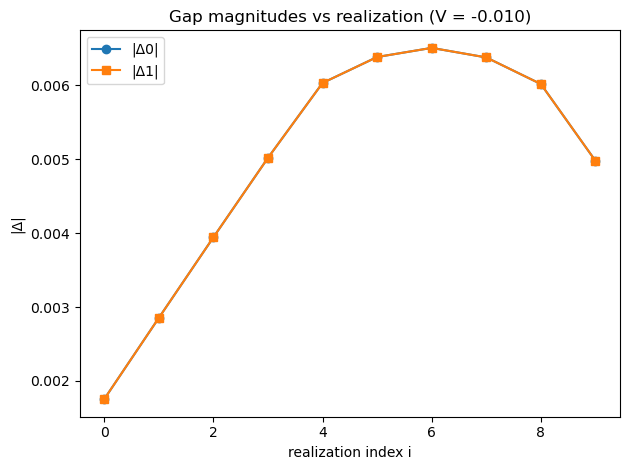

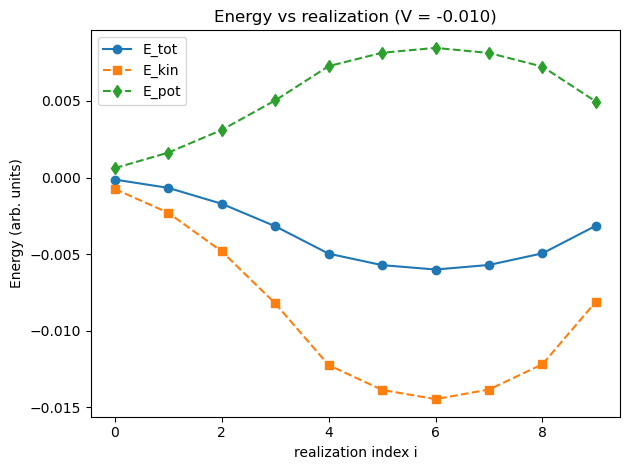

In [3]:
    # --- extract basic quantities ---
    idx = np.array([r["i"]  for r in results], int)
    D0  = np.array([r["Δ0"] for r in results], complex)
    D1  = np.array([r["Δ1"] for r in results], complex)
    MU  = np.array([r["μ"]  for r in results], float)
    #NN  = np.array([r["n"]  for r in results], float)
    RES = np.array([r["resnorm"] for r in results], float)

    # --- compute energies for ALL solutions ---
    E_kin_list = []
    E_pot_list = []
    E_tot_list = []

    for r in results:
        d0       = r["Δ0"]
        d1       = r["Δ1"]
        mu       = r["μ"]
        flat_dir = r["flat_dir"]
        V        = r["V"]     # fixed V_fixed, but read from dict

        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        # kinetic/single-particle energy
        E_kin = particle_Energy_BZ(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            T=T,
            mu=mu,
            subspace_dim=subspace_dim,
            flat_dir=flat_dir,
            average=True,
        )

        # potential energy
        E_pot = Potential_Energy(V, d0, d1)

        #E_chemical= mu *  n_target
        # total
        E_tot = E_kin + E_pot

        r["E_kin"] = E_kin
        r["E_pot"] = E_pot
        r["E_tot"] = E_tot

        E_kin_list.append(E_kin)
        E_pot_list.append(E_pot)
        E_tot_list.append(E_tot)

    E_kin_arr = np.array(E_kin_list, float)
    E_pot_arr = np.array(E_pot_list, float)
    E_tot_arr = np.array(E_tot_list, float)

    # --- plots: gaps and energies vs realization index ---
    plt.figure()
    plt.plot(idx, np.abs(D0), "o-", label="|Δ0|")
    plt.plot(idx, np.abs(D1), "s-", label="|Δ1|")
    plt.xlabel("realization index i")
    plt.ylabel("|Δ|")
    plt.title(f"Gap magnitudes vs realization (V = {V_fixed:+.3f})")
    plt.legend()
    plt.tight_layout()

    plt.figure()
    plt.plot(idx, E_tot_arr, "o-", label="E_tot")
    plt.plot(idx, E_kin_arr, "s--", label="E_kin")
    plt.plot(idx, E_pot_arr, "d--", label="E_pot")
    plt.xlabel("realization index i")
    plt.ylabel("Energy (arb. units)")
    plt.title(f"Energy vs realization (V = {V_fixed:+.3f})")
    plt.legend()
    plt.tight_layout()

    plt.show()

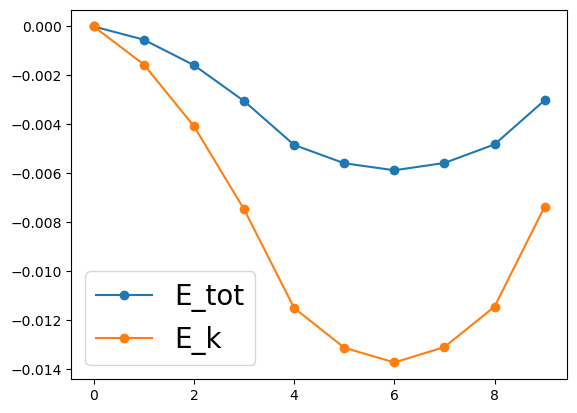

In [4]:
plt.plot(idx, E_tot_arr-E_tot_arr[0], "o-", label="E_tot")
plt.plot(idx, E_kin_arr-E_kin_arr[0], "o-", label="E_k")
#plt.plot(idx, E_pot_arr, "d--", label="E_pot")
plt.legend(fontsize=20)

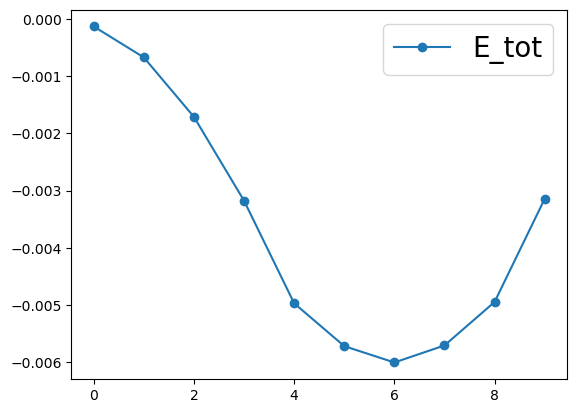

In [5]:
plt.plot(idx, E_tot_arr, "o-", label="E_tot")
#plt.plot(idx, E_kin_arr, "o-", label="E_k")
#plt.plot(idx, E_pot_arr, "d--", label="E_pot")
plt.legend(fontsize=20)

In [6]:
idx, E_tot_arr

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([-0.00013263, -0.00067408, -0.00171357, -0.00317934, -0.0049722 ,
        -0.00572035, -0.00600612, -0.00570849, -0.00494859, -0.00314607]))

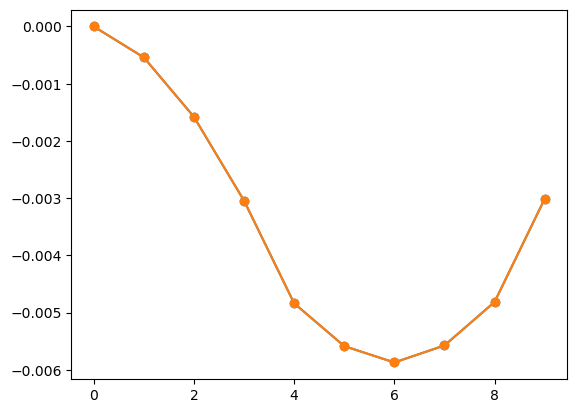

In [7]:
F=E_kin_arr+E_pot_arr+MU*4.375*2;
Omega=E_kin_arr+E_pot_arr;
plt.plot(idx, F-F[0], "o-", label="E_k")
plt.plot(idx, Omega-Omega[0], "o-", label="E_k")
#plt.plot(idx, E_pot_arr, "d--", label="E_pot")

In [8]:
-1.21618581

-1.21618581

In [9]:
E_tot_arr[8]-(-1.21618581)

np.float64(1.2112372178579112)

In [10]:
1.21618581+4.3523498864495025e-05

1.2162293334988645